# 💰 โครงการทำนายช่วงรายได้ของบุคคล (Salary Prediction Classification)

**ปัญหาและวัตถุประสงค์ (Problem Definition):**
ในยุคที่มีการแข่งขันทางเศรษฐกิจสูง การเข้าใจปัจจัยที่ส่งผลต่อรายได้ของบุคคลมีความสำคัญต่อทั้งตัวบุคคลเองในการวางแผนการศึกษาและอาชีพ และสำหรับองค์กรในการกำหนดนโยบายค่าตอบแทน โครงการนี้มีวัตถุประสงค์เพื่อสร้างโมเดล Machine Learning ในการทำนายว่าบุคคลหนึ่งๆ จะมีรายได้มากกว่า 50,000 ดอลลาร์ต่อปีหรือไม่ โดยอาศัยข้อมูลประชากรศาสตร์ เช่น อายุระดับการศึกษา สถานภาพครอบครัว และอาชีพ

**ข้อมูลที่ใช้ (Dataset):**
ใช้ชุดข้อมูล Adult Income Dataset ซึ่งประกอบด้วยคุณลักษณะต่างๆ ของบุคคล เพื่อทำนายตัวแปรเป้าหมาย (Target Variable) คือ `salary` (<=50K หรือ >50K)

**โมเดลที่เลือกใช้:** Random Forest Classifier

In [1]:
import sklearn
print(sklearn.__version__)

1.8.0


In [2]:
# นำเข้า Library ที่จำเป็นทั้งหมดสำหรับโปรเจคนี้
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าฟอนต์และสไตล์สำหรับกราฟ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Tahoma'] # รองรับภาษาไทยหากจำเป็น

# ละเว้นการแสดงข้อความเตือน (Warnings) เพื่อความสะอาดของ Notebook
import warnings
warnings.filterwarnings('ignore')

# 1. โหลดชุดข้อมูล
# สมมติว่าไฟล์ salary.csv อยู่ในโฟลเดอร์เดียวกันกับ Notebook
file_path = 'salary.csv'
df = pd.read_csv(file_path)

# แสดงข้อมูล 5 แถวแรกเพื่อตรวจสอบความถูกต้อง
print(f"จำนวนข้อมูลทั้งหมด: {df.shape[0]} แถว, {df.shape[1]} คอลัมน์")
display(df.head())

# ตรวจสอบชนิดข้อมูลของแต่ละคอลัมน์
print("\n--- ข้อมูลพื้นฐานของ Dataset ---")
df.info()

จำนวนข้อมูลทั้งหมด: 32561 แถว, 15 คอลัมน์


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



--- ข้อมูลพื้นฐานของ Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  salary          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## 🧹 Step 2: การทำความสะอาดข้อมูล (Data Cleaning) และสำรวจข้อมูล (EDA)

เพื่อให้เข้าใจลักษณะของข้อมูลและเตรียมข้อมูลให้พร้อมสำหรับโมเดล เราจะดำเนินการดังนี้:
1. **การจัดการ Missing Values:** ในชุดข้อมูลนี้ ค่าว่างมักถูกแทนที่ด้วย `?` หรือ ` ?` (มีช่องว่าง) เราจะทำการแปลงเป็น `NaN` และจัดการอุดช่องว่างด้วยค่าฐานนิยม (Mode) เนื่องจากค่าที่หายไปมักอยู่ในคอลัมน์ประเภทกลุ่ม (Categorical) เช่น อาชีพ
2. **การสำรวจข้อมูล (Exploratory Data Analysis - EDA):** วิเคราะห์การกระจายตัวของคอลัมน์เป้าหมาย (`salary`) และดูความสัมพันธ์ระหว่างตัวแปรอื่นๆ กับรายได้ เพื่อหา Insight เบื้องต้น

In [3]:
# 1. ลบช่องว่าง (Whitespace) ที่อาจติดมากับข้อมูลประเภท Text
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# 2. แปลงค่า '?' ให้เป็น NaN เพื่อให้ pandas จัดการได้ง่ายขึ้น
df.replace('?', np.nan, inplace=True)

# 3. ตรวจสอบจำนวน Missing Values ในแต่ละคอลัมน์
print("จำนวน Missing Values ก่อนจัดการ:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 4. จัดการ Missing Values อย่างมีเหตุผล
# เนื่องจากค่าที่หายไปคือ workclass, occupation และ native-country ซึ่งเป็นข้อมูลแบบกลุ่ม (Categorical)
# เราจะใช้ "ค่าฐานนิยม (Mode)" หรือค่าที่พบมากที่สุดในการเติมข้อมูล เพื่อรักษารูปแบบการกระจายตัวของข้อมูลส่วนใหญ่ไว้
for col in ['workclass', 'occupation', 'native-country']:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)

print("\nจำนวน Missing Values หลังจัดการ:")
print(df.isnull().sum().sum()) # ควรจะได้ 0

จำนวน Missing Values ก่อนจัดการ:
workclass         1836
occupation        1843
native-country     583
dtype: int64

จำนวน Missing Values หลังจัดการ:
0


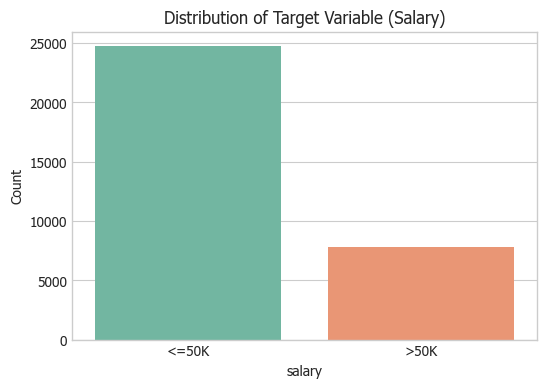

สัดส่วนผู้มีรายได้ <=50K: 75.92%
สัดส่วนผู้มีรายได้ >50K: 24.08%
ข้อสังเกต: ข้อมูลมีความไม่สมดุล (Imbalanced) ซึ่งจะต้องระวังในการเลือกใช้ Metric วัดผลในภายหลัง


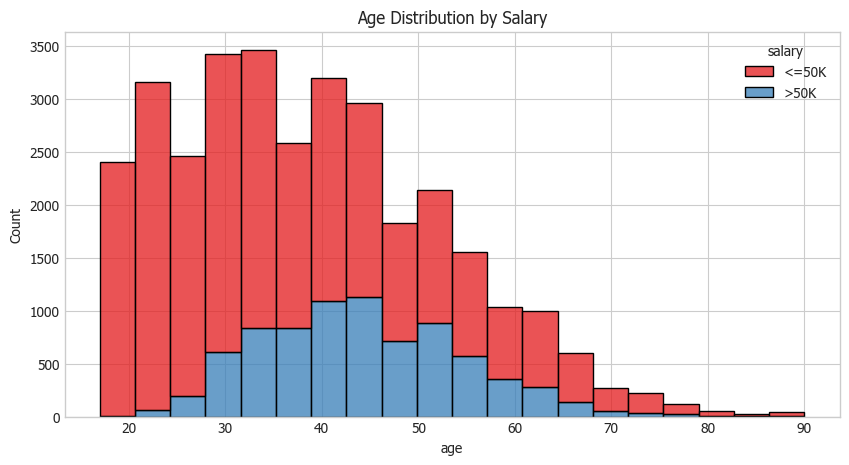

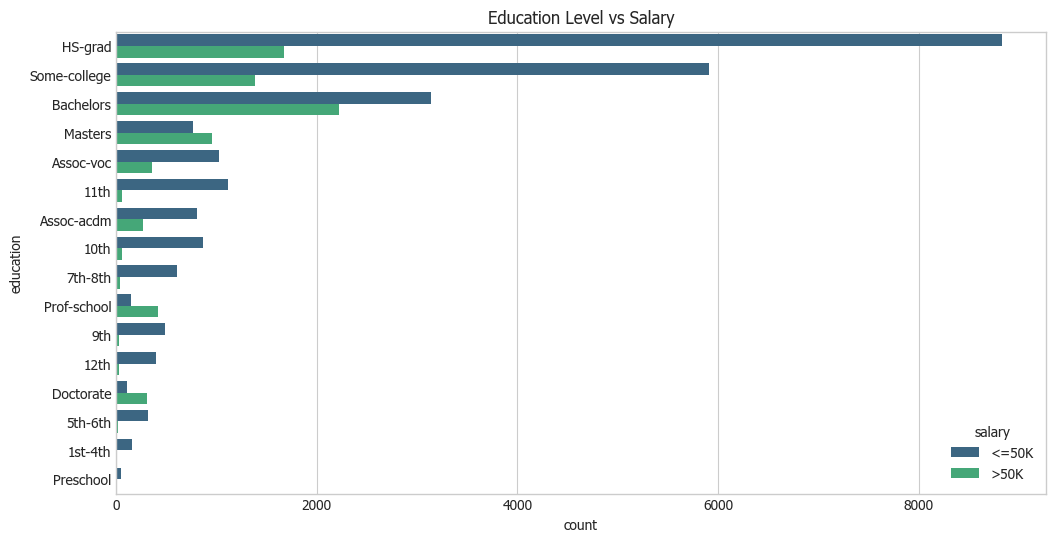

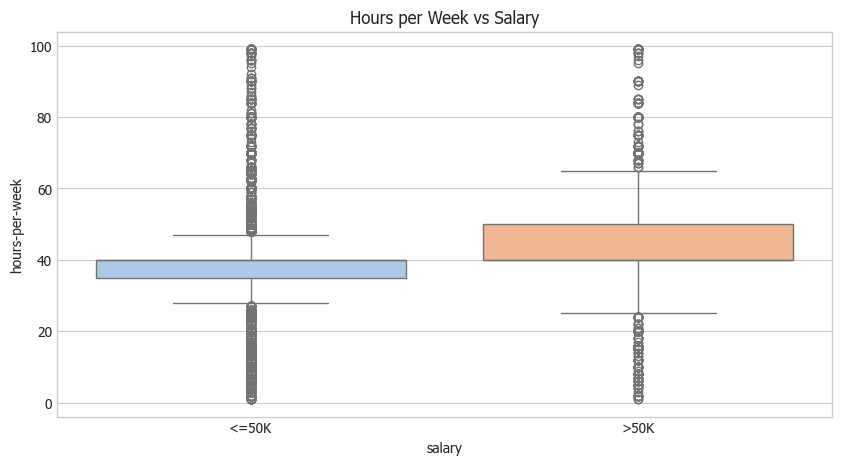

In [4]:
# 1. ดูการกระจายตัวของตัวแปรเป้าหมาย (Target Variable: salary)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='salary', palette='Set2')
plt.title('Distribution of Target Variable (Salary)')
plt.ylabel('Count')
plt.show()

# สรุปสัดส่วนของ Target
salary_counts = df['salary'].value_counts(normalize=True) * 100
print(f"สัดส่วนผู้มีรายได้ <=50K: {salary_counts['<=50K']:.2f}%")
print(f"สัดส่วนผู้มีรายได้ >50K: {salary_counts['>50K']:.2f}%")
print("ข้อสังเกต: ข้อมูลมีความไม่สมดุล (Imbalanced) ซึ่งจะต้องระวังในการเลือกใช้ Metric วัดผลในภายหลัง")

# 2. ดูการกระจายตัวของอายุ (Age) เทียบกับรายได้
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='salary', multiple='stack', bins=20, palette='Set1')
plt.title('Age Distribution by Salary')
plt.show()

# 3. ดูความสัมพันธ์ระหว่างระดับการศึกษา (Education) และรายได้
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='education', hue='salary', palette='viridis',
              order=df['education'].value_counts().index)
plt.title('Education Level vs Salary')
plt.show()

# 4. ดูความสัมพันธ์ระหว่างชั่วโมงการทำงานต่อสัปดาห์ (Hours per week) และรายได้
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='salary', y='hours-per-week', palette='pastel')
plt.title('Hours per Week vs Salary')
plt.show()

## ⚙️ Step 3: การเตรียมข้อมูล (Data Preprocessing)

เพื่อให้โมเดล Machine Learning สามารถเรียนรู้ข้อมูลได้ เราต้องทำการแปลงข้อมูลให้อยู่ในรูปแบบตัวเลขทั้งหมด โดยเราจะเตรียมสิ่งต่างๆ ดังนี้:
1. **แยก Features (X) และ Target (y):** แยกคอลัมน์ `salary` ออกมาเป็นคำตอบ
2. **Label Encoding:** แปลงคำตอบ `<=50K` ให้เป็น 0 และ `>50K` ให้เป็น 1
3. **Train/Test Split:** แบ่งข้อมูลสำหรับสอนโมเดล (Train) 80% และทดสอบโมเดล (Test) 20% โดยใช้ `stratify` เพื่อรักษาสัดส่วนของคนที่มีรายได้มากและน้อยให้เท่ากันทั้งสองชุด
4. **เตรียม Preprocessor สำหรับ Pipeline:** - **ตัวเลข (Numeric):** ใช้ `StandardScaler` ปรับสเกลให้อยู่ในมาตรฐานเดียวกัน
   - **กลุ่ม (Categorical):** ใช้ `OneHotEncoder` แปลงหมวดหมู่เป็นตัวเลข 0 และ 1

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# 1. แยก Features (X) และ Target (y)
X = df.drop('salary', axis=1)
y = df['salary']

# 2. แปลง Target ให้เป็นตัวเลข
# <=50K จะกลายเป็น 0, >50K จะกลายเป็น 1
le = LabelEncoder()
y = le.fit_transform(y)
print(f"การแปลง Target: {le.classes_[0]} -> 0, {le.classes_[1]} -> 1")

# 3. แบ่งข้อมูล Train และ Test
# ตั้ง stratify=y เพื่อให้แน่ใจว่าสัดส่วนของ class 0 และ 1 ใน Train/Test เท่ากัน
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. แยกคอลัมน์ที่เป็นตัวเลขและหมวดหมู่
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# 5. สร้าง Preprocessor (ตัวจัดการข้อมูล) เพื่อนำไปใส่ใน Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print(f"\nจำนวนข้อมูลสำหรับ Train: {X_train.shape[0]} แถว")
print(f"จำนวนข้อมูลสำหรับ Test: {X_test.shape[0]} แถว")
print("✅ เตรียม Preprocessor เรียบร้อยแล้ว พร้อมนำไปประกอบร่างกับ Model ใน Pipeline!")

การแปลง Target: <=50K -> 0, >50K -> 1

จำนวนข้อมูลสำหรับ Train: 26048 แถว
จำนวนข้อมูลสำหรับ Test: 6513 แถว
✅ เตรียม Preprocessor เรียบร้อยแล้ว พร้อมนำไปประกอบร่างกับ Model ใน Pipeline!


## 🤖 Step 4: การสร้างโมเดล (Model Development) และปรับจูนพารามิเตอร์ (Hyperparameter Tuning)

**ทำไมถึงเลือก Random Forest?**
1. **ความแม่นยำสูงและลด Overfitting:** Random Forest เป็น Ensemble Method ที่สร้าง Decision Tree หลายๆ ต้นแล้วนำผลโหวตมารวมกัน ทำให้มีความแม่นยำกว่าการใช้ Tree ต้นเดียว
2. **จัดการข้อมูลซับซ้อนได้ดี:** สามารถจัดการกับข้อมูลที่มีความสัมพันธ์แบบไม่เป็นเส้นตรง (Non-linear) ได้ดี
3. **Feature Importance:** สามารถบอกได้ว่าตัวแปรไหนมีผลต่อรายได้มากที่สุด ซึ่งเป็นประโยชน์ต่อการตีความทางธุรกิจ

**การรับมือกับ Imbalanced Data:**
จาก EDA เราพบว่าสัดส่วนคนที่มีรายได้ `<=50K` มีมากกว่า `>50K` ค่อนข้างมาก เราจึงใช้พารามิเตอร์ `class_weight='balanced'` เพื่อให้โมเดลให้ความสำคัญกับกลุ่ม `>50K` มากขึ้น และใช้ `F1-Score` เป็นเกณฑ์วัดผลตอนจูนพารามิเตอร์แทน Accuracy เพื่อความแม่นยำที่แท้จริง

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. สร้าง Pipeline ประกอบร่าง Preprocessor และ Model เข้าด้วยกัน
# ใช้ class_weight='balanced' เพื่อช่วยเรื่อง Imbalanced Dataset
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 2. กำหนดช่วงพารามิเตอร์ (Hyperparameter Grid) ที่ต้องการค้นหา
# หมายเหตุ: กำหนดไว้ขนาดเล็ก-กลาง เพื่อไม่ให้ใช้เวลารันนานเกินไป
param_grid = {
    'classifier__n_estimators': [100, 200],         # จำนวนต้นไม้
    'classifier__max_depth': [10, 20, None],        # ความลึกสูงสุดของต้นไม้
    'classifier__min_samples_split': [2, 5]         # จำนวนข้อมูลขั้นต่ำในการแบ่งกิ่ง
}

# 3. ตั้งค่า GridSearchCV พร้อมกับ 5-Fold Cross Validation
# ใช้ scoring='f1' เพราะให้ความสำคัญกับค่า Precision และ Recall ควบคู่กันไป
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,                 # 5-Fold Cross Validation
    scoring='f1',         # ใช้ F1-Score เป็นเกณฑ์ตัดสินใจ
    n_jobs=-1,            # ใช้ CPU ทุกคอร์ที่มีให้รันไวขึ้น
    verbose=2             # แสดงความคืบหน้าขณะรัน
)

# 4. ฝึกสอนโมเดล (Training) และค้นหาพารามิเตอร์ที่ดีที่สุด
print("⏳ กำลังค้นหาพารามิเตอร์ที่ดีที่สุด (อาจใช้เวลา 1-3 นาที กรุณารอสักครู่)...")
grid_search.fit(X_train, y_train)

print("\n✅ การจูนพารามิเตอร์เสร็จสิ้น!")
print(f"พารามิเตอร์ที่ดีที่สุดที่พบ: {grid_search.best_params_}")
print(f"คะแนน F1-Score (จาก 5-Fold CV) ที่ดีที่สุด: {grid_search.best_score_:.4f}")

# 5. เก็บโมเดลตัวที่ดีที่สุดไว้ใช้งานต่อ
best_rf_model = grid_search.best_estimator_

⏳ กำลังค้นหาพารามิเตอร์ที่ดีที่สุด (อาจใช้เวลา 1-3 นาที กรุณารอสักครู่)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits



✅ การจูนพารามิเตอร์เสร็จสิ้น!
พารามิเตอร์ที่ดีที่สุดที่พบ: {'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
คะแนน F1-Score (จาก 5-Fold CV) ที่ดีที่สุด: 0.7021


## 📊 Step 5: การประเมินผลโมเดล (Model Evaluation) และการแปลผล (Interpretation)

**ทำไมเราถึงไม่ดูแค่ค่า Accuracy?**
เนื่องจากข้อมูลของเราเป็นแบบ Imbalanced (คนรวย >50K มีน้อยกว่ามาก) การใช้ Accuracy เพียงอย่างเดียวอาจทำให้เราหลงกลโมเดลได้ (เช่น โมเดลทายว่า <=50K ทุกคน ก็อาจจะได้ Accuracy สูงถึง 75% แล้ว) ดังนั้นเราจึงต้องดู:
* **Precision:** ทายว่ารวยแล้วรวยจริงกี่เปอร์เซ็นต์ (ความแม่นยำในการจับถูกตัว)
* **Recall:** คนรวยทั้งหมด โมเดลจับหาเจอได้กี่เปอร์เซ็นต์ (ความครอบคลุม)
* **F1-Score:** ค่าเฉลี่ยฮาร์มอนิกของ Precision และ Recall เพื่อดูความสมดุล
* **Confusion Matrix:** เพื่อดูว่าโมเดลทายผิดประเภทไหนมากที่สุด (False Positive หรือ False Negative)

=== รายงานประเมินผลโมเดล (Classification Report) ===
              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88      4945
        >50K       0.61      0.84      0.70      1568

    accuracy                           0.83      6513
   macro avg       0.77      0.83      0.79      6513
weighted avg       0.86      0.83      0.84      6513



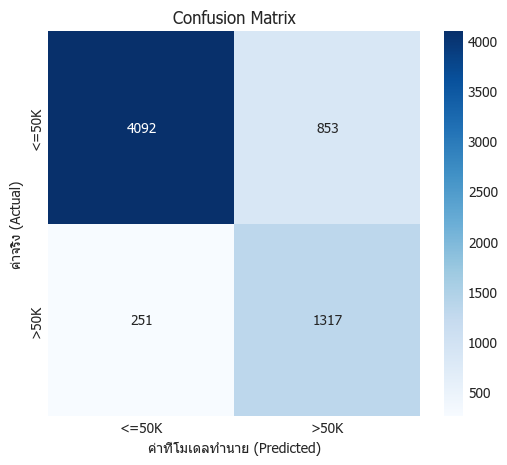

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. นำโมเดลที่ดีที่สุดมาทำนายข้อมูลชุด Test
y_pred = best_rf_model.predict(X_test)

# 2. แสดงรายงานประเมินผล (Classification Report)
print("=== รายงานประเมินผลโมเดล (Classification Report) ===")
# target_names: 0 คือ <=50K, 1 คือ >50K
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# 3. สร้างและแสดง Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix')
plt.ylabel('ค่าจริง (Actual)')
plt.xlabel('ค่าที่โมเดลทำนาย (Predicted)')
plt.show()

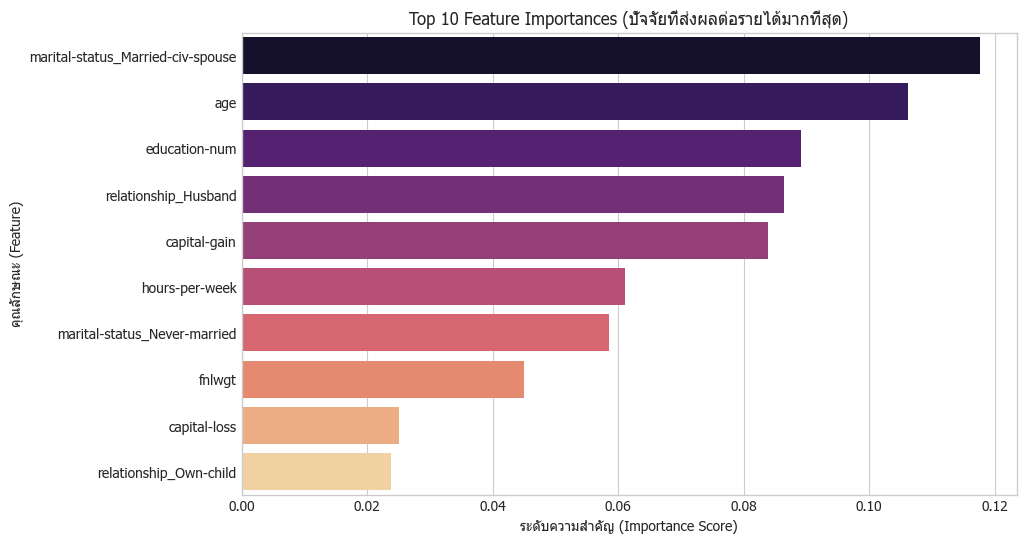


💡 สรุป Insight ทางธุรกิจและการนำไปใช้ (Business Interpretation):
1. ปัจจัยหลักที่กำหนดช่วงรายได้ของบุคคล 3 อันดับแรกคือ: marital-status_Married-civ-spouse, age, education-num
2. หากองค์กรต้องการออกแบบนโยบายสวัสดิการหรือโครงสร้างเงินเดือน ควรพิจารณาจากปัจจัยเหล่านี้เป็นหลัก
3. สำหรับบุคคลทั่วไป ข้อมูลนี้ชี้ให้เห็นว่าการลงทุนในด้านใด (เช่น การศึกษา หรือ การทำงานล่วงเวลา) จะมีผลต่อการเพิ่มโอกาสให้รายได้ทะลุ 50K ได้มากที่สุด


In [8]:
# 1. ดึงชื่อคอลัมน์ทั้งหมดออกมาจาก Preprocessor ใน Pipeline
cat_encoder = best_rf_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features_out = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_features_out)

# 2. ดึงค่าความสำคัญของตัวแปร (Feature Importances) จากโมเดล Random Forest
rf_classifier = best_rf_model.named_steps['classifier']
importances = rf_classifier.feature_importances_

# 3. สร้าง DataFrame เพื่อให้ดูง่ายและเรียงลำดับจากมากไปน้อย
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. พล็อตกราฟแสดง Top 10 ปัจจัยที่ส่งผลต่อรายได้มากที่สุด
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Feature Importances (ปัจจัยที่ส่งผลต่อรายได้มากที่สุด)')
plt.xlabel('ระดับความสำคัญ (Importance Score)')
plt.ylabel('คุณลักษณะ (Feature)')
plt.show()

# --- แปลผลในเชิง Business / ปฏิบัติ ---
print("\n💡 สรุป Insight ทางธุรกิจและการนำไปใช้ (Business Interpretation):")
top_3_features = feature_importance_df['Feature'].head(3).tolist()
print(f"1. ปัจจัยหลักที่กำหนดช่วงรายได้ของบุคคล 3 อันดับแรกคือ: {', '.join(top_3_features)}")
print("2. หากองค์กรต้องการออกแบบนโยบายสวัสดิการหรือโครงสร้างเงินเดือน ควรพิจารณาจากปัจจัยเหล่านี้เป็นหลัก")
print("3. สำหรับบุคคลทั่วไป ข้อมูลนี้ชี้ให้เห็นว่าการลงทุนในด้านใด (เช่น การศึกษา หรือ การทำงานล่วงเวลา) จะมีผลต่อการเพิ่มโอกาสให้รายได้ทะลุ 50K ได้มากที่สุด")

## 💾 Step 6: การบันทึกโมเดลเพื่อนำไปใช้งานจริง (Model Deployment Preparation)

เพื่อให้สามารถนำโมเดลไปใช้งานบน Web Application (Streamlit) ได้ตามเป้าหมายของโปรเจค เราจะทำการบันทึกโมเดล Pipeline ของเรา (ซึ่งรวบรวมทั้ง `ColumnTransformer` สำหรับจัดการข้อมูล และ `RandomForestClassifier` ที่จูนพารามิเตอร์แล้ว) ให้อยู่ในรูปแบบไฟล์ `.joblib` (หรือ `.pkl`)

ข้อดีของการบันทึกทั้ง Pipeline คือ เมื่อรับข้อมูลใหม่มาจากผู้ใช้งานผ่านหน้าเว็บ เราสามารถส่งข้อมูลดิบเข้าโมเดลได้เลยโดยไม่ต้องเขียนโค้ดแปลงข้อมูลซ้ำอีก

In [9]:
import joblib
import os

# 1. กำหนดชื่อไฟล์ที่จะใช้บันทึก
model_filename = 'salary_rf_pipeline.joblib'

# 2. ทำการบันทึก (Export) โมเดลที่ดีที่สุด
joblib.dump(best_rf_model, model_filename)

# 3. ตรวจสอบขนาดไฟล์และยืนยันการบันทึก
file_size = os.path.getsize(model_filename) / (1024 * 1024) # แปลงเป็น Megabytes
print(f"✅ บันทึกโมเดลสำเร็จ!")
print(f"📂 ชื่อไฟล์: {model_filename}")
print(f"⚖️ ขนาดไฟล์: {file_size:.2f} MB")
print("\n🎉 ยินดีด้วย! ไฟล์ Jupyter Notebook ของคุณเสร็จสมบูรณ์และพร้อมสำหรับการทำ Streamlit App แล้วครับ")

✅ บันทึกโมเดลสำเร็จ!
📂 ชื่อไฟล์: salary_rf_pipeline.joblib
⚖️ ขนาดไฟล์: 45.94 MB

🎉 ยินดีด้วย! ไฟล์ Jupyter Notebook ของคุณเสร็จสมบูรณ์และพร้อมสำหรับการทำ Streamlit App แล้วครับ
